In [9]:
from matplotlib import pyplot as plt
from functions import *

# EV and Ru(bpy)3 stock solutions now made in pH 6 buffer
# mixing limitations in cuvette, colour gradient seen

# V(Ru(bpy)3, 1 mM, buffer) = 200 ul, V(EDTA, saturated, buffer) = 1 ml, made up to 3 ml pH 6 buffer
# V(EV, 1 mM, buffer) in ul used and start times for each run, start time adjusted slightly to begin at linear region
runs = [(300, "12-11-37-000"), # 12-10-37-000 recorded start time
        (600, "12-52-20-000"), # 12-51-20-000
        (900, "13-35-20-000"), # 13-35-15-000
        (1200, "14-10-27-000"), # 14-10-27-000
        (1500, "14-45-38-000"), # 14-45-38-000
        (1800, "15-19-52-000")] # 15-19-52-000

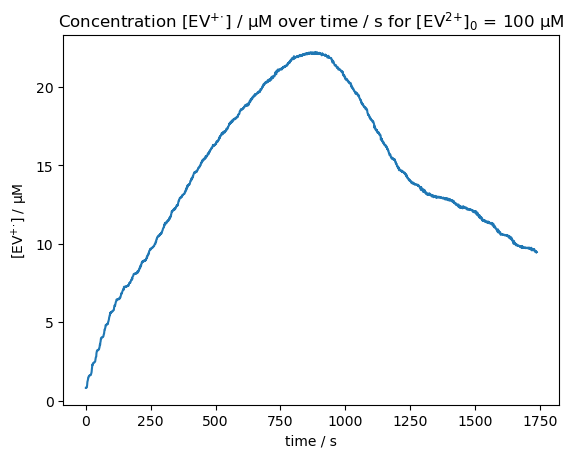

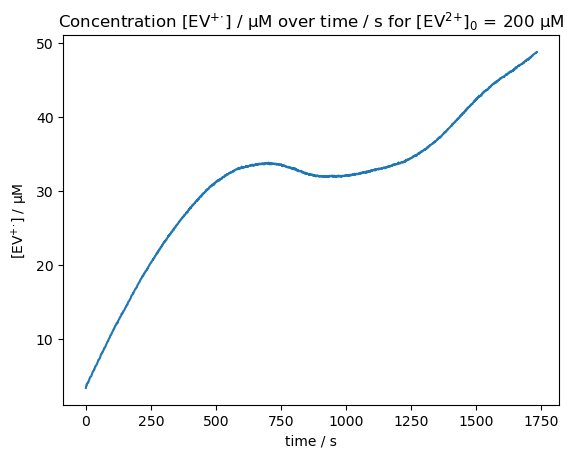

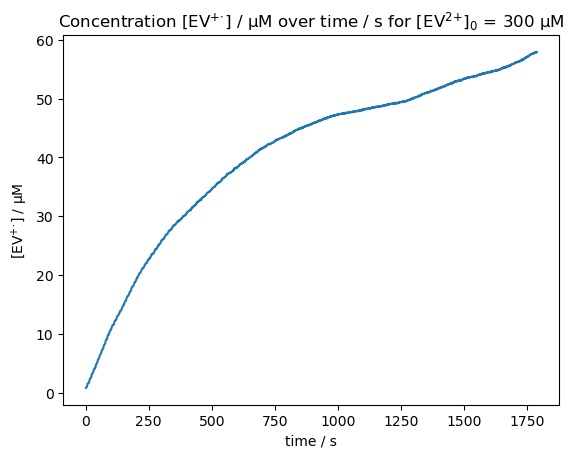

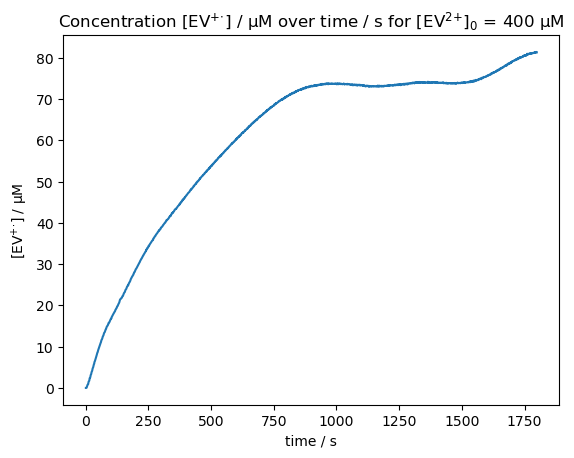

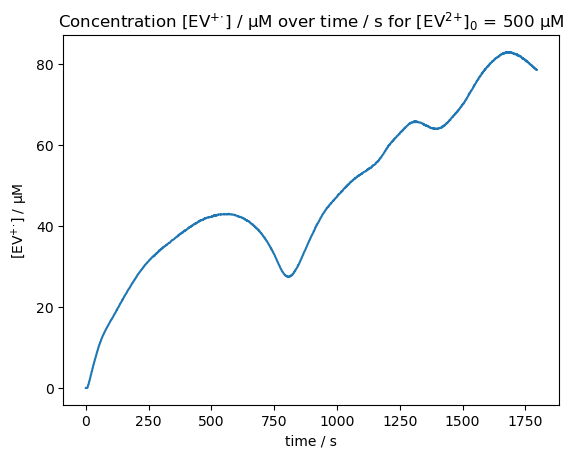

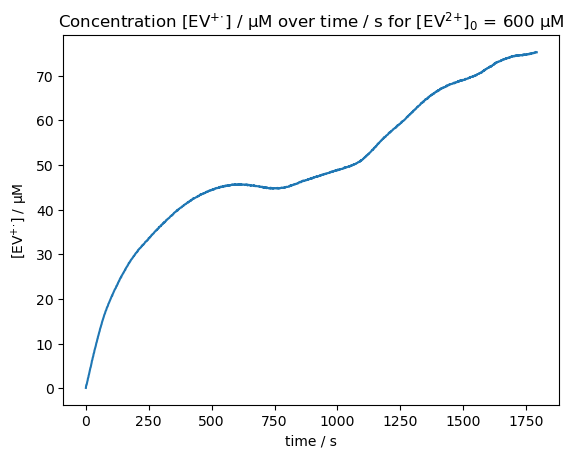

In [10]:
# concentration vs time plot for each run
for (v, start) in runs:
    data = f'./results/260630_Rubpy_EV_EDTA_Buffered/Rubpy_EV_{v}_EDTA_Buffered'
    t, c, = concvstime(data, 600, 1e-2, 1.22e6, start=start, duration=30*60)
                              # linregstart=100, r2threshold=0.99, interceptthreshold=1e-6)
    plt.plot(t, [conc*1e6 for conc in c]) # plot time in seconds, concentrations in μM
    plt.xlabel(r'time / s')
    plt.ylabel(r'[EV$^{+\!\cdot\!}$] / μM')
    plt.title(r'Concentration [EV$^{+\!\cdot\!}$] / μM over time / s for [EV$^{2\!+\!}$]$_0$ = '
              f'{solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3)*1e6:.0f} μM')
    
#     x = np.linspace(0, t[i], 100) # plot linear regression line over the initial linear region
#     y = (fit.slope*x + fit.intercept)*1e6
#     plt.plot(x, y)
#     plt.text(np.mean(x), np.mean(y)-0.025, 
#          f'slope = {fit.slope*1e8:.3f} ± {fit.stderr:.2f}\n'
#          f'intercept = {fit.intercept:.3g} ± {fit.intercept_stderr:.1g} V\n'
#          f'$r^2$ = {fit.rvalue**2:.5g}'
#          f'k = {fit.slope/c0:.3g} ± {fit.stderr/c0:.1g} s$^{-1}$')
    plt.show()

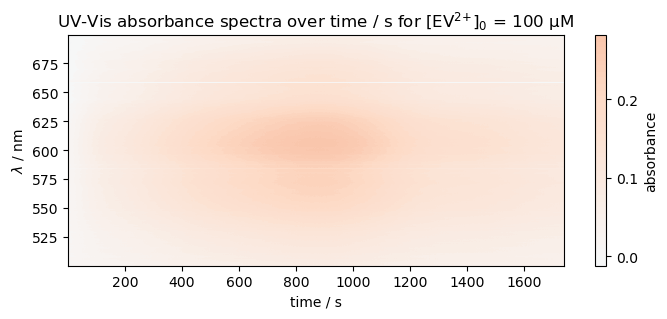

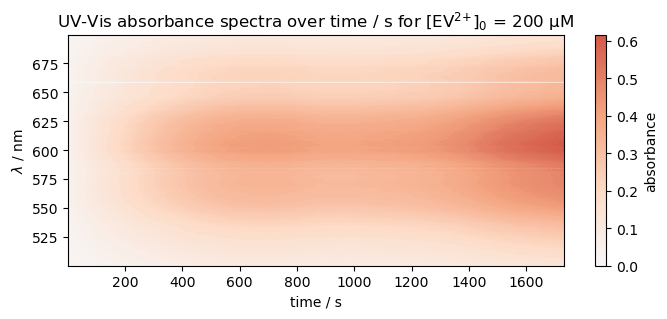

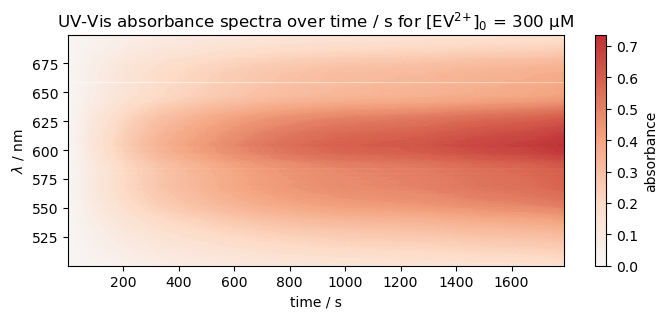

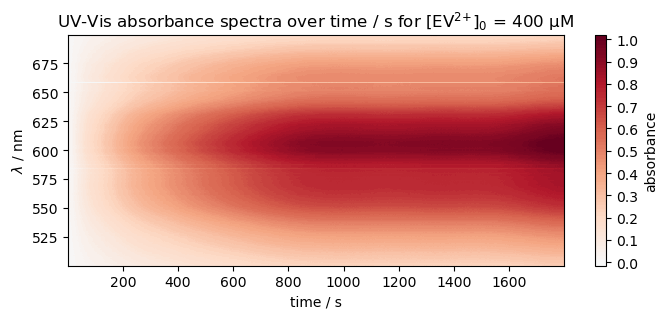

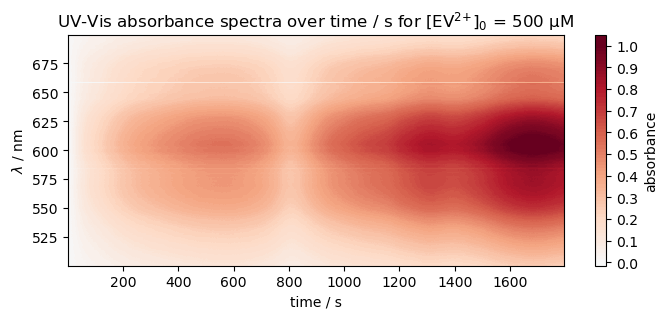

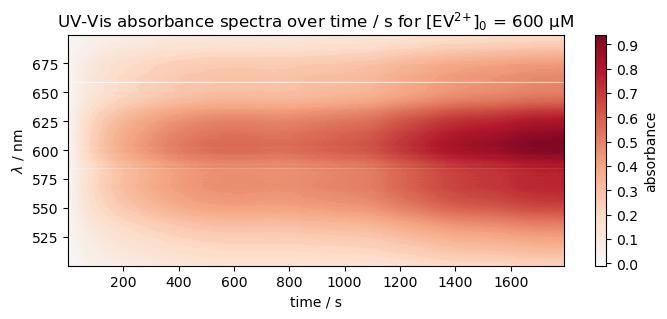

In [11]:
# uv-vis absorption spectrum over time for each run
for (v, start) in runs:
    data = f'./results/260630_Rubpy_EV_EDTA_Buffered/Rubpy_EV_{v}_EDTA_Buffered'
    t, l, a = spectrumvstime(data, start=start, duration=30*60)

    mask = (l >= 500) & (l <= 700) 
    a = a[mask, :]
    l = l[mask]

    fig, ax = plt.subplots(figsize=(8,3))
    cf = ax.contourf(t, l, a, levels=100, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(r"UV-Vis absorbance spectra over time / s for [EV$^{2\!+\!}$]$_0$ = "
                 f"{solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3)*1e6:.0f} μM")
    ax.set_xlabel("time / s")
    ax.set_ylabel(r'$\lambda$ / nm')

    cbar = plt.colorbar(cf)
    cbar.set_label("absorbance")
    cbar.set_ticks(np.arange(0, a.max(), 0.1))

    plt.show()

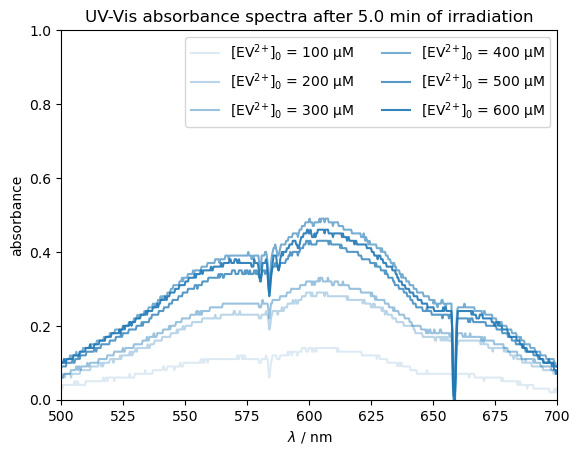

In [12]:
# plots the uv-vis absorption spectrum at time t for each run
t = 5*60
for (v, start) in runs:
    data = f'./results/260630_Rubpy_EV_EDTA_Buffered/Rubpy_EV_{v}_EDTA_Buffered'
    l, a = spectrumvstimepoints(data, [t], start=start)
    plt.plot(l, a[0], color="#1F77B4", alpha=v/2000, label=r'[EV$^{2\!+\!}$]$_0$ = '
             f'{solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3)*1e6:.0f} μM')
plt.xlim(500, 700)
plt.ylim(0,1)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.title(f'UV-Vis absorbance spectra after {t/60} min of irradiation')
plt.legend(ncols=2)
plt.show()